# ABEL Ptarmigan strong-field QED tracking example

By Carl A. Lindstrøm (University of Oslo), 8 Oct 2026

### Import ABEL framework

In [1]:
from abel import *

### Define the beam and SFQED interaction point

In [2]:
# define beam
source = SourceBasic()
source.charge = -1e10 * SI.e # [C]
source.energy = 30e9 # [eV]
source.rel_energy_spread = 0.01
source.bunch_length = 18e-6 # [m]
source.z_offset = 10e-6 # [m]
source.emit_nx, source.emit_ny = 10e-6, 10e-6 # [m rad]
source.beta_x = 0.01
source.beta_y = source.beta_x
source.num_particles = 10000

#target_sfqed = TargetSFQEDBasic()
target_sfqed = TargetSFQEDPtarmigan()
target_sfqed.laser_a0 = 5.0
target_sfqed.laser_waist_radius = 3e-6
target_sfqed.laser_duration_fwhm = 10e-15
target_sfqed.collision_angle_deg = 0.0

# set up a linac
linac = PlasmaLinac()
linac.source = source
linac.target = target_sfqed

In [3]:
# show the laser parameters
linac.target.print_laser_parameters()

Laser parameters:
> Wavelength:   800 nm
> a0:           5.0
> Duration:     10 fs FWHM
> Waist radius: 3.0 µm
------------------------------
> Intensity:    5.3e+19 W/cm^2
> Peak power:   0.01 PW
> Energy:       0.09 J


### Run simulations

In [4]:
linac.run('sfqed_example', num_shots=1, overwrite=True)

Tracked #0  SourceBasic                 (s =    0.0 m) :   E =  30.0 GeV, Q = -1.60 nC, σz =  18.0 µm, σE =  1.0%, ε =  10.1/10.03 mm-mrad
Finished Ptarmigan: 100%|█████████████████████████████████████████████████████████| 100/100 [00:19<00:00,  5.24%/s]
    ... #1  TargetSFQEDPtarmigan        (s =    0.0 m) :   E =  27.3 GeV, Q = -1.60 nC, σz =  18.0 µm, σE = 18.8%, ε =   9.3/9.27 mm-mrad


### Show the outputs

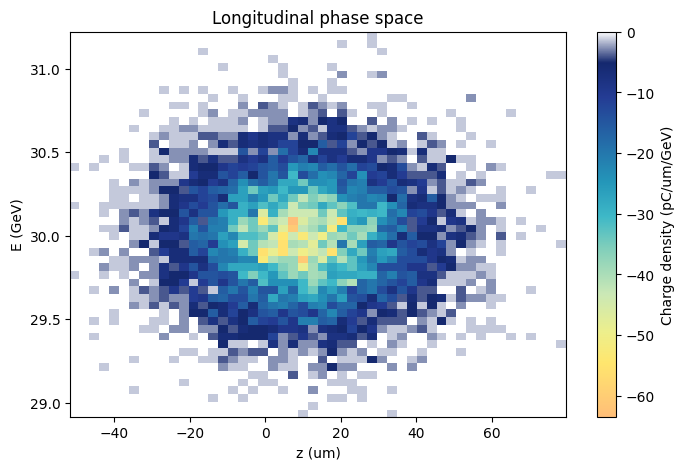

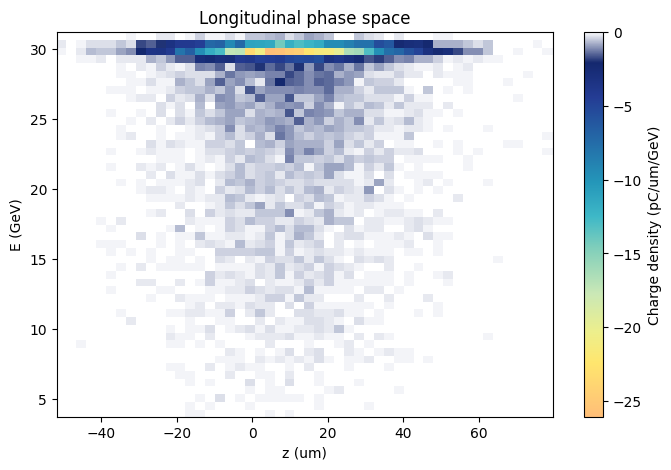

In [5]:
# plot the longitudinal phase space before and after interaction
linac.initial_beam.plot_lps()
linac.final_beam.plot_lps()

1.809150405661514
1.7805640051430798
0.38559999999999994


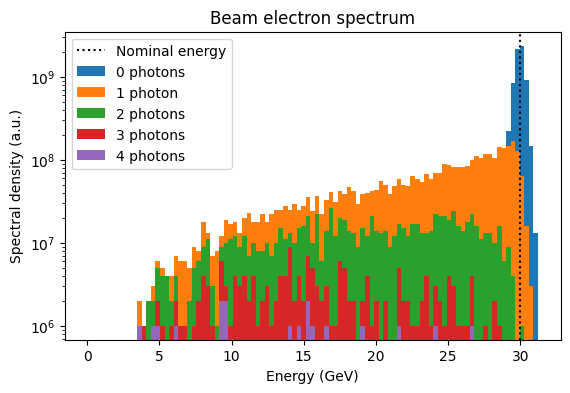

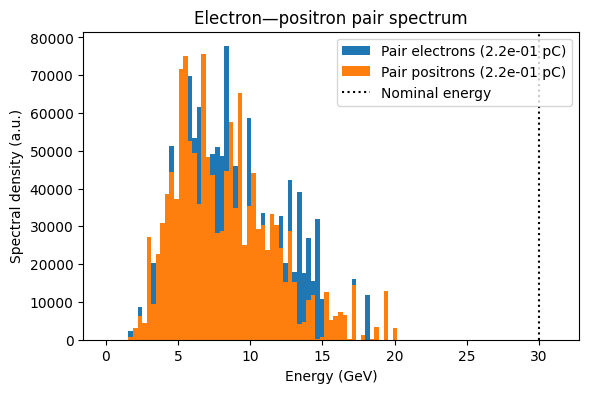

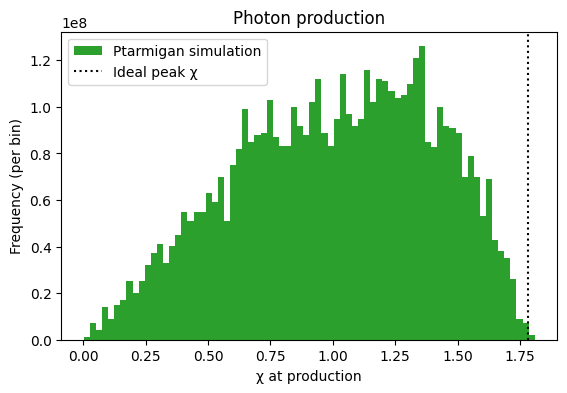

In [6]:
# show the outputs
print(linac.target.peak_chi())
print(linac.target.peak_chi_ideal())
print(linac.target.interaction_fraction())
linac.target.plot_beam_spectrum()
linac.target.plot_pair_spectrum()
linac.target.plot_photon_chis()